In [11]:
from pairs_trading.constants import DEFAULT_COINTEGRATION_ALPHA
DEFAULT_COINTEGRATION_ALPHA

0.05

In [12]:
from datetime import date
import pandas as pd
import matplotlib.pyplot as plt

from pairs_trading.data.universe import get_sp500_constituents, load_constituents_from_csv
from pairs_trading.data.stooq_loader import fetch_stooq_ohlcv, save_raw_prices
from pairs_trading.data.cleaning import clean_ohlcv, align_prices
from pairs_trading.features.returns import compute_daily_returns
from pairs_trading.selection.pair_selector import PairSelector
from pairs_trading.strategies.bollinger import BollingerStrategy
from pairs_trading.strategies.ou import OUForecastStrategy
from pairs_trading.strategies.copula import CopulaStrategy
from pairs_trading.strategies.cointegration import CointegrationStrategy
from pairs_trading.backtest.engine import BacktestEngine
from pairs_trading.backtest.metrics import (
    cumulative_return,
    annualized_return,
    volatility,
    max_drawdown,
    sharpe_ratio,
    trade_count,
)

# =========================
# Paths / settings
# =========================

from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() or (parent / "README.md").exists():
            return parent
    raise RuntimeError("Could not find project root")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
UNIVERSE_DIR = DATA_DIR / "universe"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

for d in [RAW_DIR, UNIVERSE_DIR, PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT =", PROJECT_ROOT)

AS_OF = "2024-03-31"
START = date(2024, 3, 1)
END = date(2025, 3, 31)
INTERVAL = "1d"
MAX_SYMBOLS = 100
PCA_VARIANCE = 0.8
MIN_SAMPLES = 3

PROJECT_ROOT = D:\sem 8\BTP2 - Pairs Trading


In [13]:
# =========================
# Helpers
# =========================
def save_fig(name: str):
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved figure -> {path}")

def load_or_download_universe(as_of: str) -> pd.DataFrame:
    cached = UNIVERSE_DIR / "sp500_constituents.csv"
    if cached.exists():
        print("Loading cached universe CSV")
        return load_constituents_from_csv(str(cached))

    print("Downloading universe...")
    df = get_sp500_constituents(as_of)
    df.to_csv(cached, index=False)
    print(f"saved universe -> {cached}")
    return df

def load_or_download_price(symbol: str) -> pd.DataFrame:
    safe = symbol.replace("/", "-").replace(".", "_")
    path = RAW_DIR / f"{safe}.{INTERVAL}.csv"

    # if path.exists() and path.stat().st_size > 0:
    #     df = pd.read_csv(path, parse_dates=["date"], index_col="date")
    #     return clean_ohlcv(df)

    try:
        df = fetch_stooq_ohlcv(symbol, INTERVAL, START, END)
        if df is None or df.empty:
            return pd.DataFrame()
        save_raw_prices(df, str(path))
        return clean_ohlcv(df)
    except Exception as e:
        print(f"[WARN] {symbol}: {e}")
        return pd.DataFrame()

def build_or_load_processed_prices(universe: pd.DataFrame, force_rebuild: bool = False) -> pd.DataFrame:
    path = PROCESSED_DIR / "prices.parquet"
    # if path.exists() and not force_rebuild:
    #     print("Loading cached processed dataset")
    #     return pd.read_parquet(path)

    symbols = universe["Symbol"].dropna().astype(str).tolist()[:MAX_SYMBOLS]
    print(f"Downloading up to {len(symbols)} symbols")

    data = {}
    for sym in symbols:
        df = load_or_download_price(sym)
        if df is not None and not df.empty:
            data[sym] = df

    aligned = align_prices(data)
    aligned.to_parquet(path)
    print(f"saved processed prices -> {path}")
    return aligned

def summarize_backtest(result: pd.DataFrame, initial_capital: float = 100000.0) -> dict:
    equity = result["equity_curve"]
    trades = result.attrs.get("trades", pd.DataFrame())

    return {
        "final_equity": float(equity.iloc[-1]),
        "cumulative_return": cumulative_return(equity),
        "annualized_return": annualized_return(equity),
        "volatility": volatility(equity),
        "max_drawdown": max_drawdown(equity),
        "sharpe_ratio": sharpe_ratio(equity),
        "trade_count": trade_count(trades),
    }

In [14]:
# =========================
# 1) Universe
# =========================
universe = load_or_download_universe(AS_OF)
display(universe.head())

# =========================
# 2) Prices
# =========================
prices = build_or_load_processed_prices(universe)
display(prices.head())

# =========================
# 3) Pair selection
# =========================
returns = compute_daily_returns(prices)

selector = PairSelector(
    target_variance=PCA_VARIANCE,
    min_samples=MIN_SAMPLES,
)
selector.fit(prices)
selected_pairs = selector.select_pairs()

print("clusters:", len(selector.clusters))
print("candidates:", len(selector.generate_candidates()))

pairs_path = TABLES_DIR / "selected_pairs.csv"
selected_pairs.to_csv(pairs_path, index=False)
print(f"saved selected pairs -> {pairs_path}")

display(selected_pairs.head(10))

Loading cached universe CSV


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,hideFounded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


saved processed prices -> D:\sem 8\BTP2 - Pairs Trading\data\processed\prices.parquet


,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,CBOE,CBRE,CDW,COR,CNC,CNP,CF,CRL,SCHW,CHTR
date,,,,,,,,,,,,,,,,,,,,,
2024-03-01,91.86,83.94,118.62,178.91,380.99,570.93,202.64,15.47,80.43,139.06,...,187.02,92.98,247.32,237.03,77.98,27.44,82.50,264.38,66.47,293.16
2024-03-04,91.44,85.10,120.04,177.05,383.71,567.94,205.36,16.07,79.74,142.86,...,189.36,92.16,246.67,235.80,78.32,27.94,79.86,258.92,67.64,279.06
2024-03-05,92.69,83.69,118.48,179.16,376.88,544.84,205.13,16.15,80.83,144.35,...,190.25,91.88,244.97,235.31,77.40,27.89,79.52,261.27,68.10,280.85
2024-03-06,92.52,84.50,119.34,181.06,380.83,543.09,210.63,16.22,82.16,146.22,...,187.62,92.30,247.19,234.68,77.59,28.30,81.58,263.44,68.10,276.33
2024-03-07,92.62,86.65,120.92,180.57,386.91,556.04,211.38,16.16,82.29,149.31,...,183.81,92.86,248.34,237.63,79.66,28.31,83.88,270.27,68.19,282.00


clusters: 5
candidates: 66
saved selected pairs -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\selected_pairs.csv


,asset_left,asset_right,cointegration_pvalue,beta,hurst,half_life,mean_crosses_per_year
0,APO,BAC,0.012449,0.135302,0.403681,8.112969,29.756458
1,ARES,BAC,0.036415,0.162625,0.428907,9.017975,26.966790


In [15]:
# =========================
# 4) Pick one pair to test strategies
# =========================
if selected_pairs.empty:
    raise RuntimeError("No pairs selected. Try increasing MAX_SYMBOLS or relaxing filters.")

pair_row = selected_pairs.iloc[0]
left = pair_row["asset_left"]
right = pair_row["asset_right"]

pair_data = prices[[left, right]].dropna()
print(f"Testing pair: {left} / {right}")
display(pair_data.head())

# =========================
# Benchmark: SPY
# =========================
spy_df = load_or_download_price("SPY")

if spy_df is None or spy_df.empty:
    raise RuntimeError("Could not load SPY benchmark data.")

# Use close prices and align to the same date range as your pair data
spy = spy_df["close"].dropna().copy()
spy.name = "SPY"

# Align SPY to the same dates as the price matrix / test period
spy = spy.reindex(prices.index).dropna()

# Buy-and-hold equity curve starting from the same capital
spy_returns = spy.pct_change().fillna(0.0)
spy_equity_curve = 100000.0 * (1.0 + spy_returns).cumprod()

spy_result = pd.DataFrame(
    {
        "spy_price": spy,
        "spy_returns": spy_returns,
        "equity_curve": spy_equity_curve,
    },
    index=spy.index,
)

spy_metrics = {
    "strategy": "SPY_buy_and_hold",
    "final_equity": float(spy_equity_curve.iloc[-1]),
    "cumulative_return": cumulative_return(spy_equity_curve),
    "annualized_return": annualized_return(spy_equity_curve),
    "volatility": volatility(spy_equity_curve),
    "max_drawdown": max_drawdown(spy_equity_curve),
    "sharpe_ratio": sharpe_ratio(spy_equity_curve),
    "trade_count": 0,
}

spy_metrics_df = pd.DataFrame([spy_metrics]).set_index("strategy")

# =========================
# 5) Run strategies
# =========================
engine = BacktestEngine(
    initial_capital=100000.0,
    notional_per_trade=100000.0,
    transaction_cost_bps=0,
    slippage_bps=0,
)

strategies = {
    "bollinger": BollingerStrategy(window=20, num_std=2.0, exit_std=0.5),
    "ou": OUForecastStrategy(window=20, confidence=0.98, n_paths=20000, entry_z=1.0, exit_z=0.2),
    "copula": CopulaStrategy(entry_quantile=0.15, exit_quantile=0.5),
    "cointegration": CointegrationStrategy(window=20, entry_z=2.0, exit_z=0.5),
}

results = {}
metrics_rows = []

for name, strat in strategies.items():
    print(f"Running strategy: {name}")
    strat.fit(pair_data)
    res = engine.run(strat, pair_data)
    results[name] = res

    metrics = summarize_backtest(res)
    metrics["strategy"] = name
    metrics_rows.append(metrics)

metrics_df = pd.DataFrame(metrics_rows).set_index("strategy").sort_values(
    by="cumulative_return", ascending=False
)

metrics_df = pd.concat([metrics_df, spy_metrics_df], axis=0).sort_values(
    by="cumulative_return", ascending=False
)

metrics_path = TABLES_DIR / "strategy_metrics_with_spy.csv"
metrics_df.to_csv(metrics_path)
print(f"saved metrics -> {metrics_path}")
display(metrics_df)

Testing pair: APO / BAC


,APO,BAC
date,,
2024-03-01,111.01,34.35
2024-03-04,111.36,35.15
2024-03-05,109.41,35.39
2024-03-06,108.80,35.42
2024-03-07,110.91,35.63


Running strategy: bollinger
Running strategy: ou
Running strategy: copula
Running strategy: cointegration
saved metrics -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\strategy_metrics_with_spy.csv


,final_equity,cumulative_return,annualized_return,volatility,max_drawdown,sharpe_ratio,trade_count
strategy,,,,,,,
copula,134404.223777,0.323860,0.299329,0.099421,-0.038720,2.684567,180
bollinger,120886.027090,0.208860,0.193670,0.081889,-0.045378,2.203288,26
cointegration,120886.027090,0.208860,0.193670,0.081889,-0.045378,2.203288,26
SPY_buy_and_hold,110805.842666,0.108058,0.100504,0.136389,-0.100353,0.770433,0
ou,101130.719770,0.011307,0.010549,0.129010,-0.109968,0.145596,33


saved figure -> D:\sem 8\BTP2 - Pairs Trading\outputs\figures\equity_curve_comparison_vs_spy.png


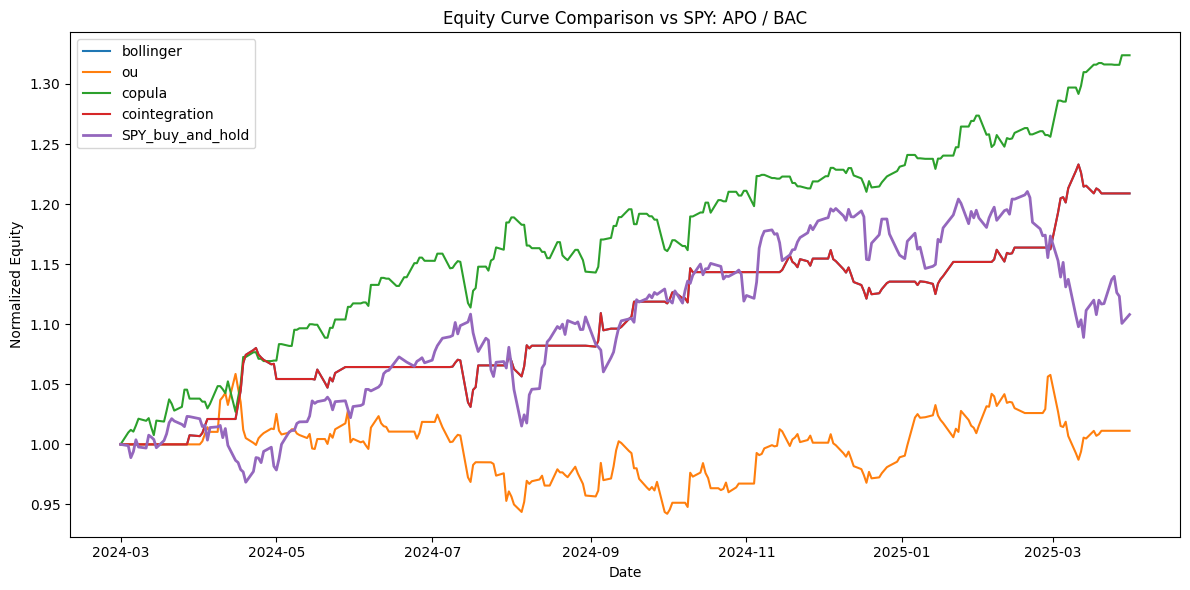

In [16]:
# =========================
# Chart 1: equity curve comparison vs SPY
# =========================
plt.figure(figsize=(12, 6))

for name, res in results.items():
    equity = res["equity_curve"] / res["equity_curve"].iloc[0]
    plt.plot(equity.index, equity.values, label=name)

spy_norm = spy_result["equity_curve"] / spy_result["equity_curve"].iloc[0]
plt.plot(spy_norm.index, spy_norm.values, label="SPY_buy_and_hold", linewidth=2)

plt.title(f"Equity Curve Comparison vs SPY: {left} / {right}")
plt.xlabel("Date")
plt.ylabel("Normalized Equity")
plt.legend()
save_fig("equity_curve_comparison_vs_spy.png")
plt.show()

saved figure -> D:\sem 8\BTP2 - Pairs Trading\outputs\figures\drawdown_comparison_vs_spy.png


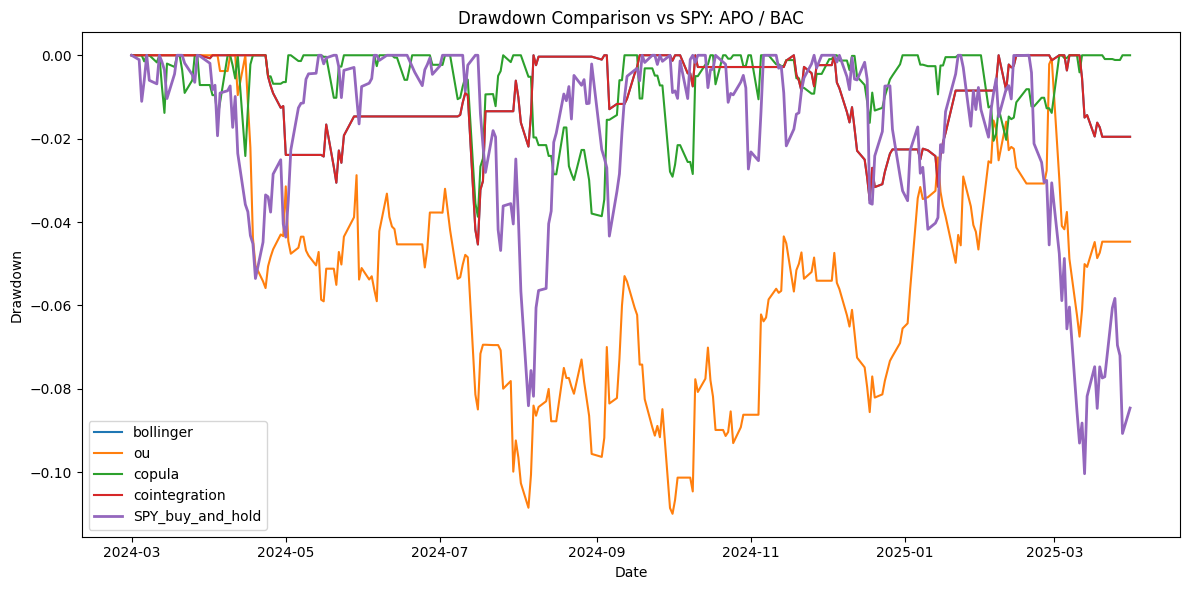

saved figure -> D:\sem 8\BTP2 - Pairs Trading\outputs\figures\excess_return_vs_spy.png


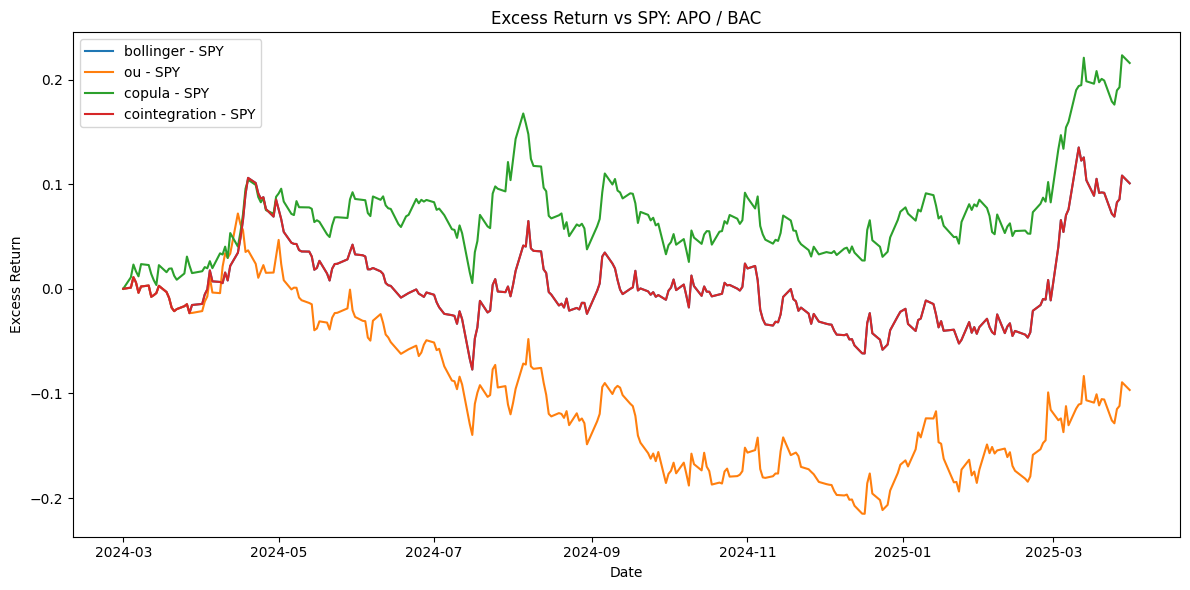

saved figure -> D:\sem 8\BTP2 - Pairs Trading\outputs\figures\best_strategy_spread_signal.png


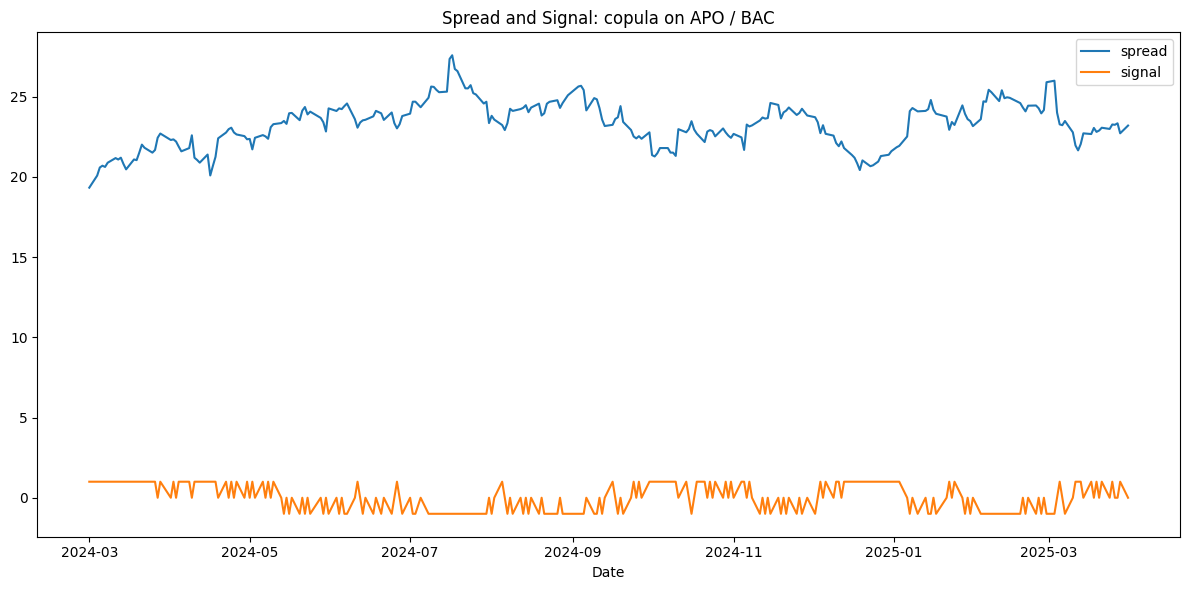

saved figure -> D:\sem 8\BTP2 - Pairs Trading\outputs\figures\cumulative_return_bar.png


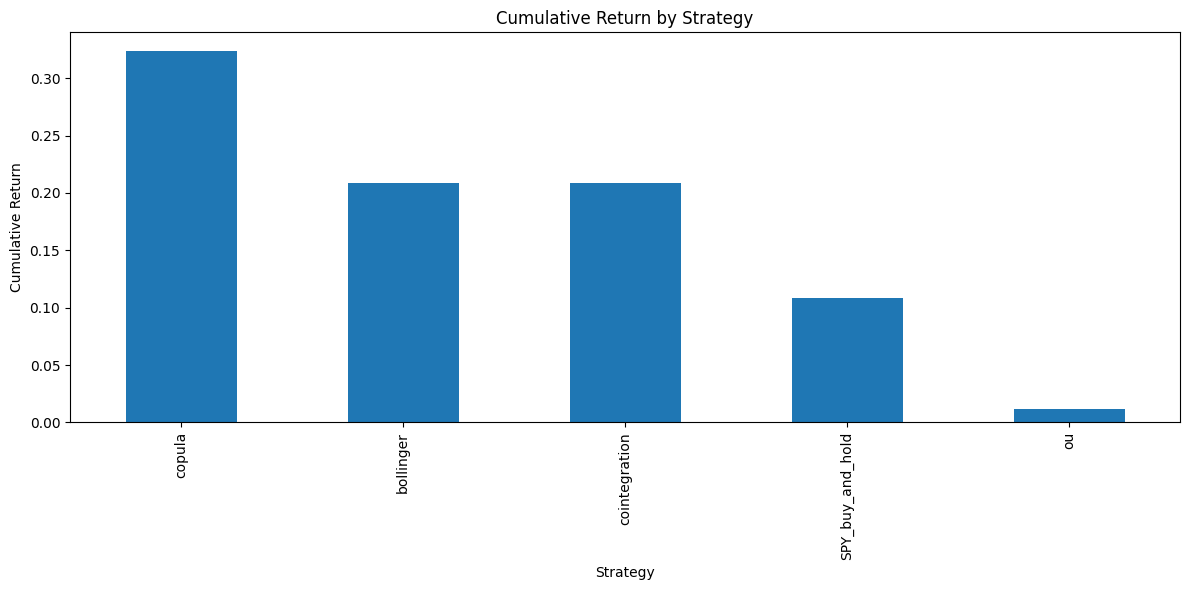

saved backtest -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\bollinger_backtest.csv
saved backtest -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\ou_backtest.csv
saved backtest -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\copula_backtest.csv
saved backtest -> D:\sem 8\BTP2 - Pairs Trading\outputs\tables\cointegration_backtest.csv


In [17]:


# =========================
# Chart 2: drawdown comparison vs SPY
# =========================
plt.figure(figsize=(12, 6))

for name, res in results.items():
    equity = res["equity_curve"]
    dd = equity / equity.cummax() - 1.0
    plt.plot(dd.index, dd.values, label=name)

spy_dd = spy_result["equity_curve"] / spy_result["equity_curve"].cummax() - 1.0
plt.plot(spy_dd.index, spy_dd.values, label="SPY_buy_and_hold", linewidth=2)

plt.title(f"Drawdown Comparison vs SPY: {left} / {right}")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
save_fig("drawdown_comparison_vs_spy.png")
plt.show()

# =========================
# Chart 3: excess return vs SPY
# =========================
plt.figure(figsize=(12, 6))

spy_total_return = spy_result["equity_curve"] / spy_result["equity_curve"].iloc[0] - 1.0

for name, res in results.items():
    strat_total_return = res["equity_curve"] / res["equity_curve"].iloc[0] - 1.0
    aligned = pd.concat([strat_total_return, spy_total_return], axis=1).dropna()
    excess = aligned.iloc[:, 0] - aligned.iloc[:, 1]
    plt.plot(excess.index, excess.values, label=f"{name} - SPY")

plt.title(f"Excess Return vs SPY: {left} / {right}")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
save_fig("excess_return_vs_spy.png")
plt.show()

# =========================
# Chart 4: spread + signals for best strategy
# =========================
best_strategy = metrics_df.index[0]
best_res = results[best_strategy]

plt.figure(figsize=(12, 6))
plt.plot(best_res.index, best_res["spread"], label="spread")
plt.plot(best_res.index, best_res["signal"], label="signal")
plt.title(f"Spread and Signal: {best_strategy} on {left} / {right}")
plt.xlabel("Date")
plt.legend()
save_fig("best_strategy_spread_signal.png")
plt.show()

# =========================
# Chart 5: metric comparison bar chart
# =========================
plt.figure(figsize=(12, 6))
metrics_df["cumulative_return"].plot(kind="bar")
plt.title("Cumulative Return by Strategy")
plt.xlabel("Strategy")
plt.ylabel("Cumulative Return")
save_fig("cumulative_return_bar.png")
plt.show()

# =========================
# 10) Optional: save each strategy result
# =========================

for name, res in results.items():
    out = TABLES_DIR / f"{name}_backtest.csv"
    res.to_csv(out)
    print(f"saved backtest -> {out}")